In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from Jan.utils import checks, reassemble

import Johannes

from Johannes.utils import data_handling
from Johannes.check_n1_stab import check_n1_stab

import yaml


In [2]:
NCLUSTERS = 200 #100#200
groupsize = 60
TEMP_RESOLUTION = 3 #H
load_shedding = True
path_syntax = 'new'
# 
# added by Jan
s_max_pu = 0.7#config["lines"]["s_max_pu"]

co2_relaxation = 1.0 #config['co2_relaxation']

n_subnetworks = int(np.ceil(8760 / TEMP_RESOLUTION / groupsize))

# path = "/2.0"

if path_syntax == 'new':
    # added by Jan
    s_max_pu_path = f"s_max_pu_{s_max_pu}/" if s_max_pu != "" else "" 


    co2_relaxation_path = f"co2_rel_{co2_relaxation}/" if co2_relaxation else ""
    path =  co2_relaxation_path + s_max_pu_path
    
elif path_syntax == 'old':
    s_max_pu_path = ''
    path = f"{co2_relaxation}"

In [3]:
Co2l = 0.2
# nLopf_path = f"../workflow/submodules/pypsa-eur/results/networks/elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.nc"
# nLopf = pypsa.Network(nLopf_path) #Lopf network
nPrep = pypsa.Network(f"../workflow/{path}/prenetworks/elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}_prepared.nc") #prepared network
nLopf = nPrep
xtra = 'method_Martha/'
nSclopf = pypsa.Network(f"../workflow/{path}/postnetworks/{xtra}sclopf-elec_s_" + f"{NCLUSTERS}" + f"_ec_lv1.0_Co2L{Co2l}.nc") #SCLOPF network


snapshots = nLopf.snapshots

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
INFO:pypsa.io:Imported network elec_s_200_ec_lv1.0_Co2L0.2_prepared.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_200_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


In [4]:
m = nSclopf.optimize.create_model()  # the return value is the model, let's use it directly!

DatetimeIndex(['2013-03-17 00:00:00', '2013-03-17 03:00:00',
               '2013-03-17 06:00:00', '2013-03-17 09:00:00',
               '2013-03-17 12:00:00', '2013-03-17 15:00:00',
               '2013-03-17 18:00:00', '2013-03-17 21:00:00',
               '2013-03-18 00:00:00', '2013-03-18 03:00:00',
               ...
               '2013-04-07 06:00:00', '2013-04-07 09:00:00',
               '2013-04-07 12:00:00', '2013-04-07 15:00:00',
               '2013-04-07 18:00:00', '2013-04-07 21:00:00',
               '2013-04-08 00:00:00', '2013-04-08 03:00:00',
               '2013-04-08 06:00:00', '2013-04-08 09:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=180, freq=None)
DatetimeIndex(['2013-05-08 12:00:00', '2013-05-08 15:00:00',
               '2013-05-08 18:00:00', '2013-05-08 21:00:00',
               '2013-05-09 00:00:00', '2013-05-09 03:00:00',
               '2013-05-09 06:00:00', '2013-05-09 09:00:00',
               '2013-05-09 12:00:00', '2013-05-0

In [6]:
sus = m.variables["StorageUnit-state_of_charge"]
m.add_constraints(sus >= 50, name="StorageUnit-minimum_soc")



Constraint `StorageUnit-minimum_soc` (snapshot: 2920, StorageUnit: 552):
------------------------------------------------------------------------
[2013-01-01 00:00:00, AL1 0 hydro]: +1 StorageUnit-state_of_charge[2013-01-01 00:00:00, AL1 0 hydro] ≥ 50.0
[2013-01-01 00:00:00, AT1 0 PHS]: +1 StorageUnit-state_of_charge[2013-01-01 00:00:00, AT1 0 PHS]     ≥ 50.0
[2013-01-01 00:00:00, AT1 0 hydro]: +1 StorageUnit-state_of_charge[2013-01-01 00:00:00, AT1 0 hydro] ≥ 50.0
[2013-01-01 00:00:00, AT1 1 PHS]: +1 StorageUnit-state_of_charge[2013-01-01 00:00:00, AT1 1 PHS]     ≥ 50.0
[2013-01-01 00:00:00, AT1 1 hydro]: +1 StorageUnit-state_of_charge[2013-01-01 00:00:00, AT1 1 hydro] ≥ 50.0
[2013-01-01 00:00:00, AT1 2 PHS]: +1 StorageUnit-state_of_charge[2013-01-01 00:00:00, AT1 2 PHS]     ≥ 50.0
[2013-01-01 00:00:00, AT1 2 hydro]: +1 StorageUnit-state_of_charge[2013-01-01 00:00:00, AT1 2 hydro] ≥ 50.0
		...
[2013-12-31 21:00:00, SE2 3 H2]: +1 StorageUnit-state_of_charge[2013-12-31 21:00:00, SE2 3 H

In [8]:
k = nSclopf.optimize.create_model()

DatetimeIndex(['2013-03-17 00:00:00', '2013-03-17 03:00:00',
               '2013-03-17 06:00:00', '2013-03-17 09:00:00',
               '2013-03-17 12:00:00', '2013-03-17 15:00:00',
               '2013-03-17 18:00:00', '2013-03-17 21:00:00',
               '2013-03-18 00:00:00', '2013-03-18 03:00:00',
               ...
               '2013-04-07 06:00:00', '2013-04-07 09:00:00',
               '2013-04-07 12:00:00', '2013-04-07 15:00:00',
               '2013-04-07 18:00:00', '2013-04-07 21:00:00',
               '2013-04-08 00:00:00', '2013-04-08 03:00:00',
               '2013-04-08 06:00:00', '2013-04-08 09:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=180, freq=None)
DatetimeIndex(['2013-05-08 12:00:00', '2013-05-08 15:00:00',
               '2013-05-08 18:00:00', '2013-05-08 21:00:00',
               '2013-05-09 00:00:00', '2013-05-09 03:00:00',
               '2013-05-09 06:00:00', '2013-05-09 09:00:00',
               '2013-05-09 12:00:00', '2013-05-0

In [9]:
k.constraints

linopy.model.Constraints
------------------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Line-fix-s-lower (snapshot, Line-fix)
 * Line-fix-s-upper (snapshot, Line-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * StorageUnit-fix-p_dispatch-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_dispatch-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-p_store-upper (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_of_charge-lower (snapshot, StorageUnit-fix)
 * StorageUnit-fix-state_of_charge-upper (snapshot, StorageUnit-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * Bus-meshed-nodal_balance (Bus-meshed, snapshot)
 * Kirchhoff-Voltage-Law (snapshot, cycles)
 * StorageUnit-energy_balance (snapshot, StorageUnit)
 * GlobalConstraint-CO2Limit

### Export to graphml fromat for further investigations

In [61]:
import networkx as nx

In [63]:
# import
network = data_handling.load_pypsa_network(nLopf_path, False)
G = data_handling.build_networkx_graph(network, snet_index=0)


G2 = G.copy()
# debug
# for node, attrs in G2.nodes(data=True):
#     for key, value in attrs.items():
#         if isinstance(value, tuple) or isinstance(value, list) :
#             print(f"Knoten {node}: Attribut {key} hat den Typ {type(value)}")

# for u, v, attrs in G2.edges(data=True):
#     for key, value in attrs.items():
#         if isinstance(value, tuple) or isinstance(value, list):
#             print(f"Kante {u}-{v}: Attribut {key} hat den Typ {type(value)}, value = {value}")

# change attribute types
for node, attrs in G2.nodes(data=True):
    for key, value in attrs.items():
        if isinstance(value, tuple):
            G2.nodes[node][key] = str(value)  # Tuple in String umwandeln

for u, v, attrs in G2.edges(data=True):
    for key, value in attrs.items():
        # if key == 'line_index':
        #     G2.edges[u, v][key] = value[0]
        if isinstance(value, tuple) or isinstance(value, list):
            G2.edges[u, v][key] = str(value)  # Tuple in String umwandeln

bridges = list(nx.bridges(G))
print('Die Anzahl der Brücken ist:' + str(len(bridges)))


#export
output_path = f"elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.graphml"
nx.write_graphml(G2, output_path)

INFO:pypsa.io:Imported network elec_s_400_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


Die Anzahl der Brücken ist:25


/srv/data/jlange/PYPSA3/sclopf-iter/notebooks/Johannes/utils/data_handling.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  snet = pypsa_network.sub_networks["obj"][snet_index]


# Reassemble

In [3]:
for Co2l in ['0.2']: #['0.05', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6']:
    reassemble.reassemble(path=path,NCLUSTERS=NCLUSTERS,Co2l=Co2l,n_subnetworks=n_subnetworks)

FileNotFoundError: [Errno 2] No such file or directory: '/srv/data/jlange/PYPSA3/sclopf-iter/workflows_max_pu_0.7/1.0/prenetworks/elec_s_20_ec_lv1.0_Co2L0.2_prepared.nc'

# Load Network(s)

In [18]:
Co2l = 0.2

nLopf = pypsa.Network(f"../workflow/submodules/pypsa-eur/results/networks/elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.nc") #Lopf network
nPrep = pypsa.Network(f"../workflow{path}/prenetworks/elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}_prepared.nc") #prepared network
n = nLopf

# # #### SCLOPF Network ####
# path_to_sclopf_network = f"../workflow{path}/postnetworks/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0_Co2L{Co2l}.nc"
# nSclopf = pypsa.Network(path_to_sclopf_network) #sclopf network
# i = nSclopf


# k = 10
# ### sclopf network for one rolling horizon ###
# network_part = pypsa.Network(f"../workflow{path}/postnetworks/Co2L{Co2l}/sclopf-elec_s_{NCLUSTERS}_ec_lv1.0-{k}.nc")

# # i = network_part



snapshots = nLopf.snapshots #[ nLopf.snapshots < max(network_part.snapshots)] #nSclopf.snapshots[nSclopf.snapshots <= max(network_part.snapshots)]#
# snapshots



INFO:pypsa.io:Imported network elec_s_400_ec_lv1.0_Co2L0.2.nc has buses, carriers, generators, global_constraints, lines, links, loads, shapes, storage_units


FileNotFoundError: [Errno 2] No such file or directory: '/srv/data/jlange/PYPSA3/sclopf-iter/workflows_max_pu_0.5/1.0/prenetworks/elec_s_400_ec_lv1.0_Co2L0.2_prepared.nc'

### Abgleich Sclopf Leistung mit Lopf Leistung

In [16]:
nLopf.determine_network_topology()
to_delete = []

for i, sub in nLopf.sub_networks.iterrows():
    buses = sub.obj.buses()
    if len(buses) == 1:
        to_delete += list(buses.index)
        
        
island_carrierdata = nLopf.generators.loc[nLopf.generators.query("bus in @to_delete").index].groupby("carrier")["p_nom"].sum()
lopf_carrierdata = nLopf.generators.groupby("carrier")["p_nom"].sum()
Sclopf_carrierdata = nSclopf.generators.groupby("carrier")["p_nom"].sum()

copied_data = Sclopf_carrierdata.copy()
for carrier in copied_data.keys():
    if carrier in lopf_carrierdata:
        # print(carrier)
        copied_data[carrier] -=  lopf_carrierdata[carrier]
    if carrier in island_carrierdata:
        copied_data[carrier] +=  island_carrierdata[carrier]

    
    

copied_data

carrier
CCGT             0.0
OCGT             0.0
biomass          0.0
coal             0.0
geothermal       0.0
lignite          0.0
load             0.0
nuclear          0.0
offwind-ac       0.0
offwind-dc       0.0
offwind-float    0.0
oil              0.0
onwind           0.0
ror              0.0
solar            0.0
solar-hsat       0.0
Name: p_nom, dtype: float64

### Distribution of Loadshedding Occurences

Text(0.5, 0, 'p [%]')

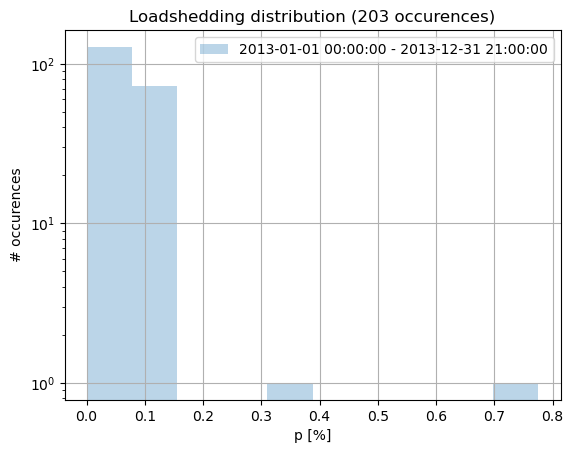

In [17]:
network = nSclopf
loadshedd = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index")\
            .mul(network.generators.sign).T.groupby(network.generators["carrier"]).sum().loc['load']
total_power = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
                network.generators["carrier"]).sum().sum(axis = 0)

fig, ax = plt.subplots()
ax.set_yscale('log')
y = loadshedd/total_power*100
mask = y > 0
y[mask].hist(alpha = 0.3,label = f"{min(network.snapshots)} - {max(network.snapshots)}")
plt.legend()
plt.title(f'Loadshedding distribution ({sum(mask)} occurences)')
plt.ylabel('# occurences')
plt.xlabel('p [%]')

# Check Contingency

In [45]:
# check_n1_stab(path_to_pypsa_network = path_to_sclopf_network, use_sclopf=True)


## CO2 Levels

In [47]:


lopf_CO2_global = nLopf.global_constraints["constant"]["CO2Limit"]
sclopf_emission_by_co2l = checks.get_emissions(nSclopf)

print(f"The emissions in the sclopf are {sclopf_emission_by_co2l/lopf_CO2_global*100}% of those in the lopf")

The emissions in the sclopf are 176.69336457864193% of those in the lopf


## Plot energy mix

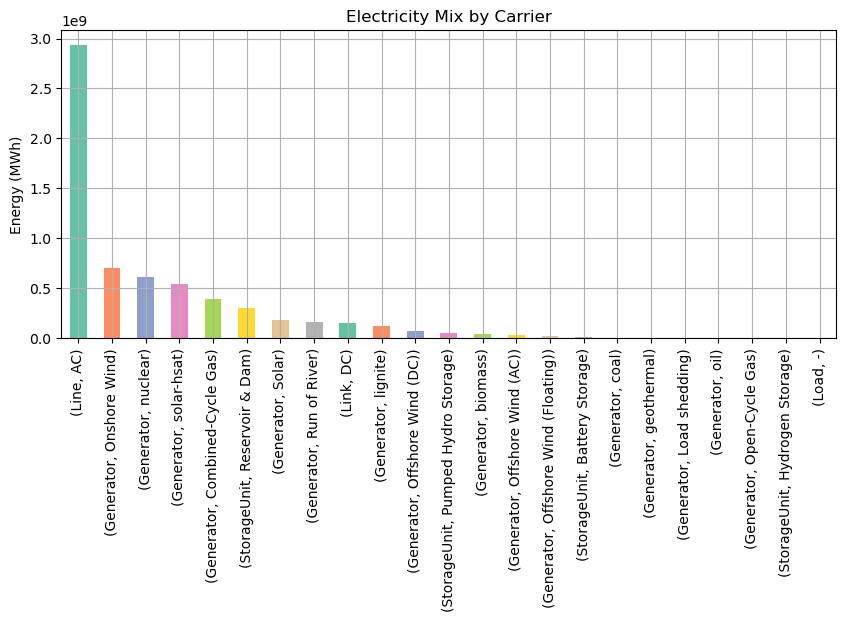

In [18]:
import seaborn as sns

fig,ax = plt.subplots(1,1,figsize = [10,4])
energy_mix = nLopf.generators_t.p.sum(axis=0)

# Group by energy carrier
energy_mix_by_carrier = supply = nSclopf.statistics().Supply
#energy_mix.groupby(nLopf.generators.carrier).sum()

energy_mix_sorted = energy_mix_by_carrier.sort_values(ascending=False)

# Use a color palette from seaborn (for example, 'Set2')
colors = sns.color_palette("Set2", len(energy_mix_sorted))

# Plot the sorted energy mix as a bar chart
energy_mix_sorted.plot(kind="bar", color=colors)
# plt.xticks(rotation=45)
ax.grid()

# Add labels and title
ax.set_ylabel("Energy (MWh)")
plt.title("Electricity Mix by Carrier")
plt.show()

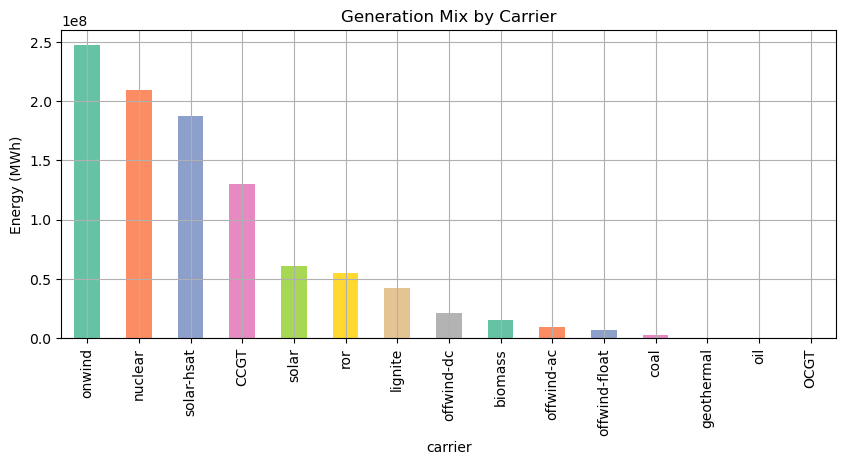

In [49]:
import seaborn as sns

fig,ax = plt.subplots(1,1,figsize = [10,4])
energy_mix = nLopf.generators_t.p.sum(axis=0)

# Group by energy carrier
energy_mix_by_carrier = energy_mix.groupby(nLopf.generators.carrier).sum()

energy_mix_sorted = energy_mix_by_carrier.sort_values(ascending=False)

# Use a color palette from seaborn (for example, 'Set2')
colors = sns.color_palette("Set2", len(energy_mix_sorted))

# Plot the sorted energy mix as a bar chart
energy_mix_sorted.plot(kind="bar", color=colors)

ax.grid()

# Add labels and title
ax.set_ylabel("Energy (MWh)")
plt.title("Generation Mix by Carrier")
plt.show()

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the energy balance data
energy_balance = nSclopf.statistics.energy_balance(aggregate_time=False).loc[:, :, "AC"].droplevel(0).iloc[:, :10]

# Sum values by carrier and filter
energy_balance_grouped = energy_balance.groupby("carrier").sum().where(lambda x: np.abs(x) > 1).fillna(0)

# # Separate positive and negative values
# positive_values = energy_balance_grouped.where(energy_balance_grouped > 0, 0)
# negative_values = energy_balance_grouped.where(energy_balance_grouped < 0, 0)

# # Create subplots
# fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# # Plot positive values
# positive_values.T.plot.area(ax=ax[0], color=colors, stacked=True, title="Energy Balance Timeseries (Positive)")
# ax[0].legend(bbox_to_anchor=(1, 1), loc="upper left", title="Carrier", ncol=2)
# ax[0].set_ylabel("Positive Energy Balance")

# # Plot negative values
# negative_values.T.plot.area(ax=ax[1], color=colors, stacked=True, title="Energy Balance Timeseries (Negative)")
# ax[1].legend(bbox_to_anchor=(1, 1), loc="upper left", title="Carrier", ncol=2)
# ax[1].set_ylabel("Negative Energy Balance")
# ax[1].set_xlabel("Time")

# plt.tight_layout()
# plt.show()


In [51]:
energy_balance_grouped.sum(axis=1).sum()

0.48830000043381006

## Yearly Plots

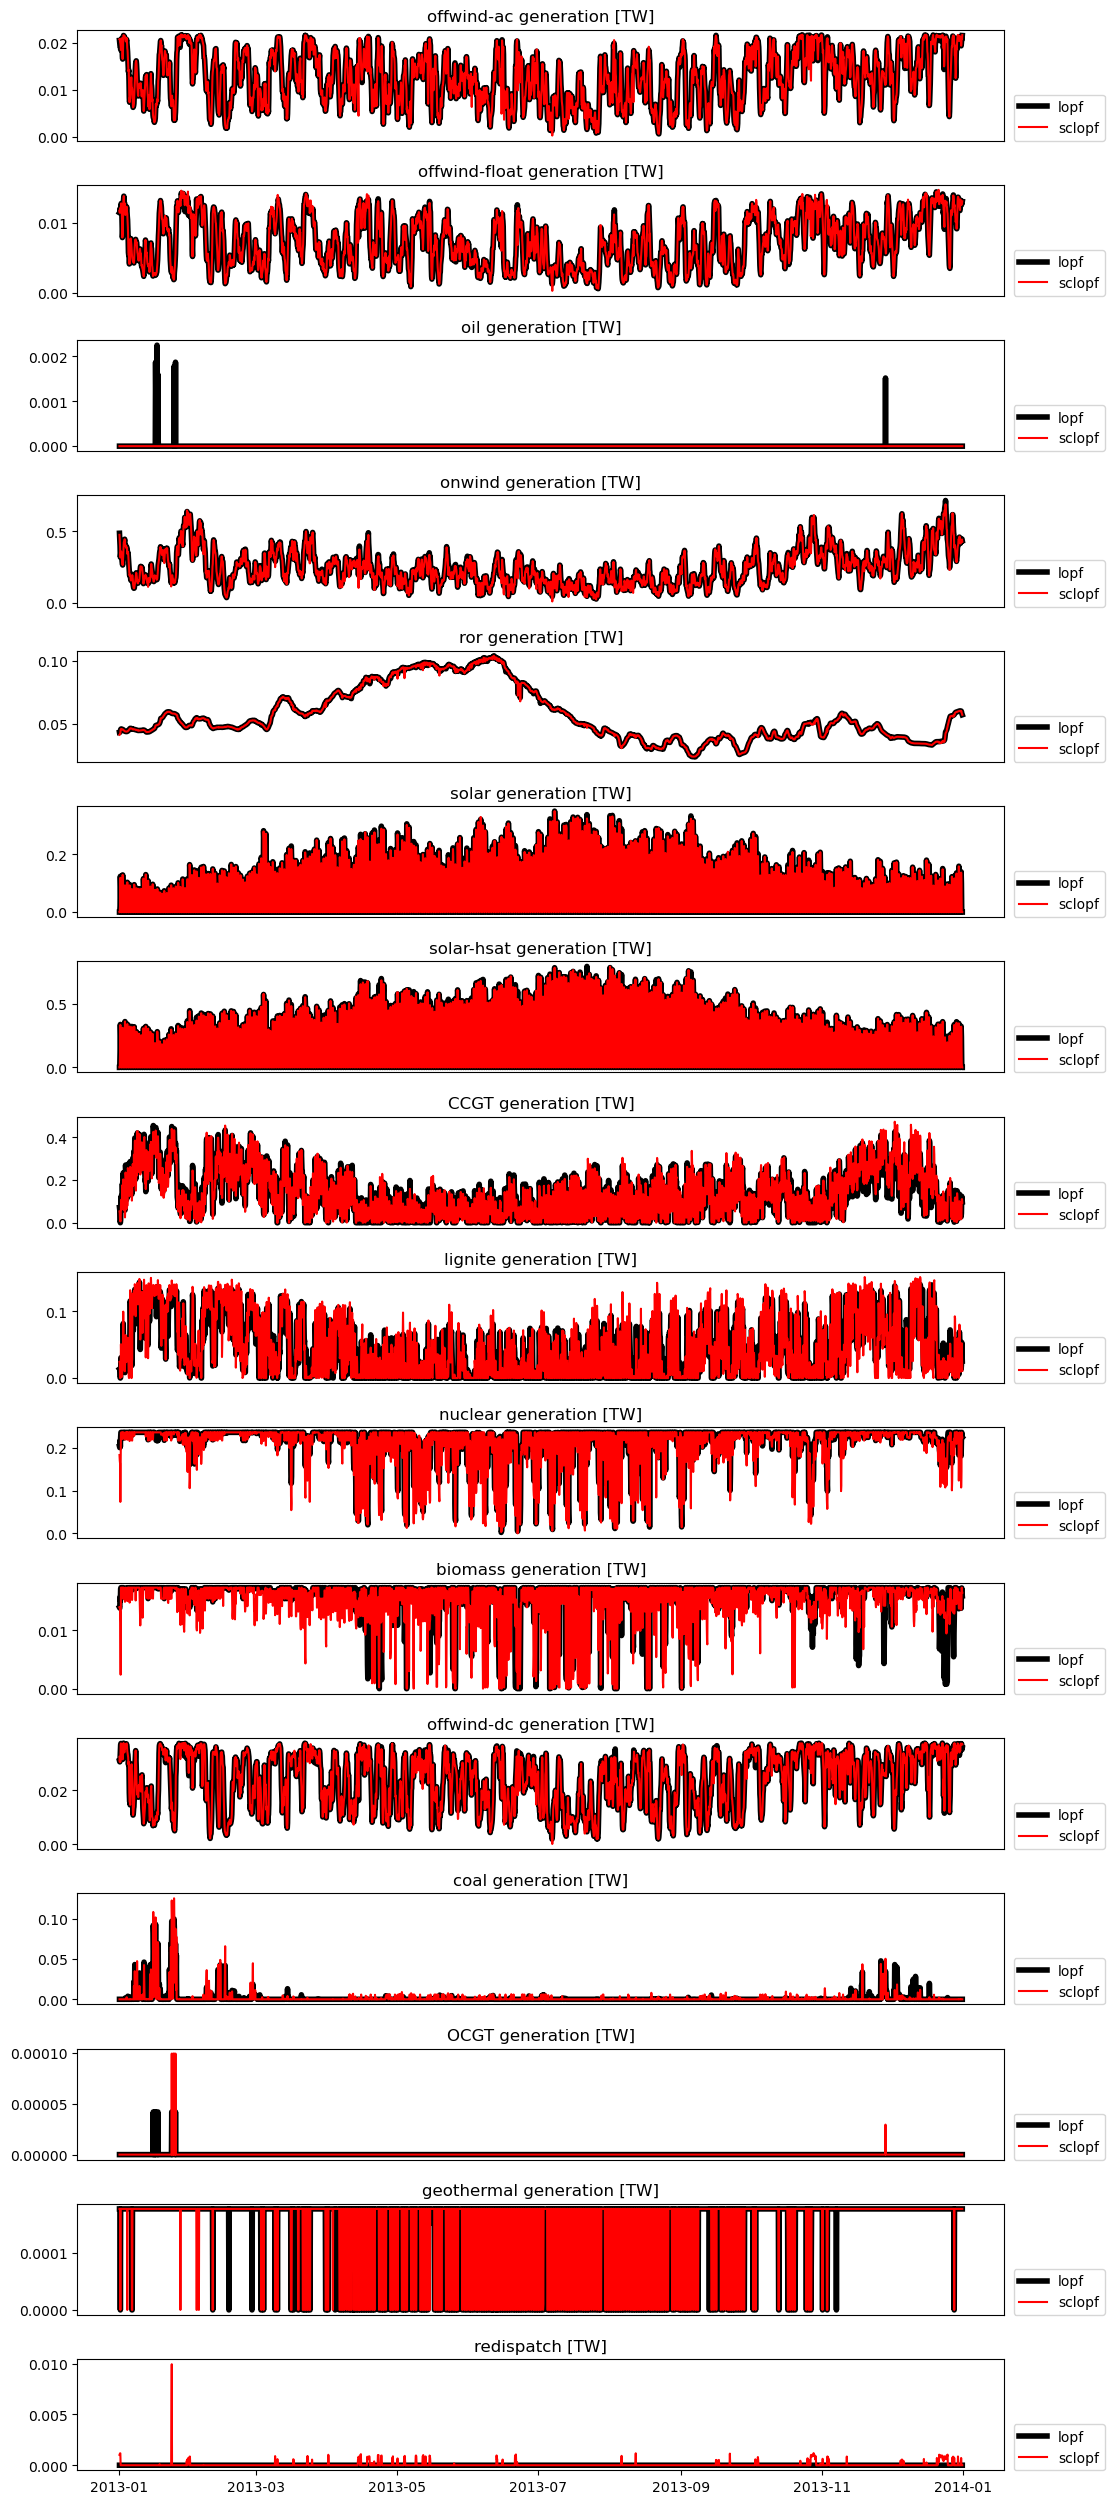

In [20]:
fig, axes = plt.subplots(len(nSclopf.generators.carrier.unique()), 1, figsize=(10, 25))
fig.tight_layout()

c = 0
techsu = nSclopf.generators.carrier.unique()
for ax in axes:
    tech = techsu[c]
    disp_i = (
        nSclopf.generators_t.p
        .multiply(nSclopf.snapshot_weightings.objective,axis=0).T
        .multiply(nSclopf.generators.sign,axis=0)
        .groupby(nSclopf.generators.carrier).sum()
        .T[tech].loc[snapshots]/1e6
    )
    if tech == "load":
        disp_n = 0*disp_i
        ax.set_title("redispatch [TW]")
    else:
        disp_n = nLopf.generators_t.p.multiply(nLopf.snapshot_weightings.objective,axis=0).T.groupby(nLopf.generators.carrier).sum().T[tech].loc[snapshots]/1e6
        ax.set_title(tech + " generation [TW]")
        ax.set_xticks([], [])

    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.plot(disp_i, color="red", zorder=3, label="sclopf")
    ax.legend(loc=[1.01, 0])
    c = c+1

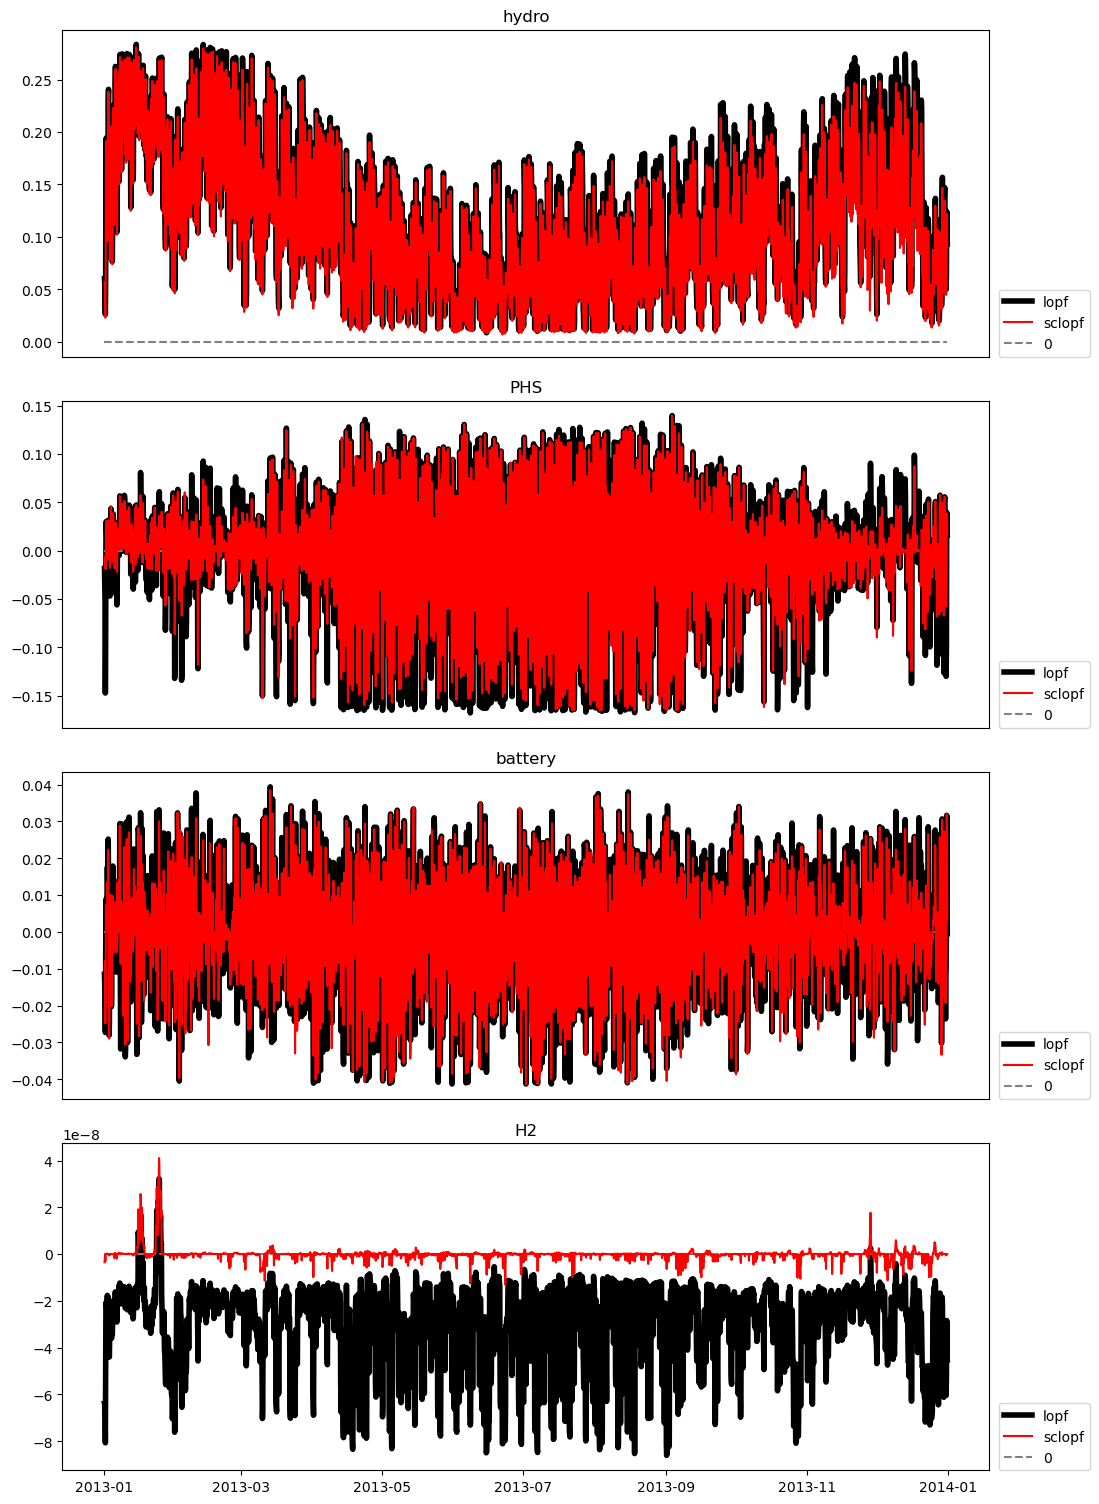

In [21]:
fig, axes = plt.subplots(len(nLopf.storage_units.carrier.unique()), 1, figsize=(10, 15))
fig.tight_layout()

c = 0
techsu = nLopf.storage_units.carrier.unique()
for ax in axes:
    tech = techsu[c]
    disp_n = nLopf.storage_units_t.p.multiply(nLopf.snapshot_weightings.objective,axis=0).T.groupby(nLopf.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6
    disp_a = nSclopf.storage_units_t.p_max_pu.multiply(nSclopf.snapshot_weightings.objective,axis=0).multiply(nSclopf.storage_units.p_nom).T.groupby(nLopf.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6
    disp_s = nSclopf.storage_units_t.p_min_pu.multiply(nSclopf.snapshot_weightings.objective,axis=0).multiply(nSclopf.storage_units.p_nom).T.groupby(nLopf.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6
    disp_i = nSclopf.storage_units_t.p.multiply(nSclopf.snapshot_weightings.objective,axis=0).T.groupby(nSclopf.storage_units.carrier).sum().T[tech].loc[snapshots]/1e6

    ax.set_title(tech) # + " dispatch (solid) / what's allowed (area) [TW]"
    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.plot(disp_i, color="red", zorder=3, label="sclopf")
    # ax.plot(disp_a, "--", color="red", linewidth=0.5, zorder=10, label="sclopf upper bound")
    # # ax.fill_between(snapshots, disp_a, disp_s, color="red", alpha=0.1, label="allowed area for dispatch")
    # ax.plot(disp_s, "--", color="red", linewidth=0.5, zorder=10, label="sclopf lower bound")
    ax.plot([snapshots[0], snapshots[-1]], [0, 0], "--", color="gray", label="0")
    ax.legend(loc=[1.01, 0])
    if tech != "H2": ax.set_xticks([], [])
    c = c+1

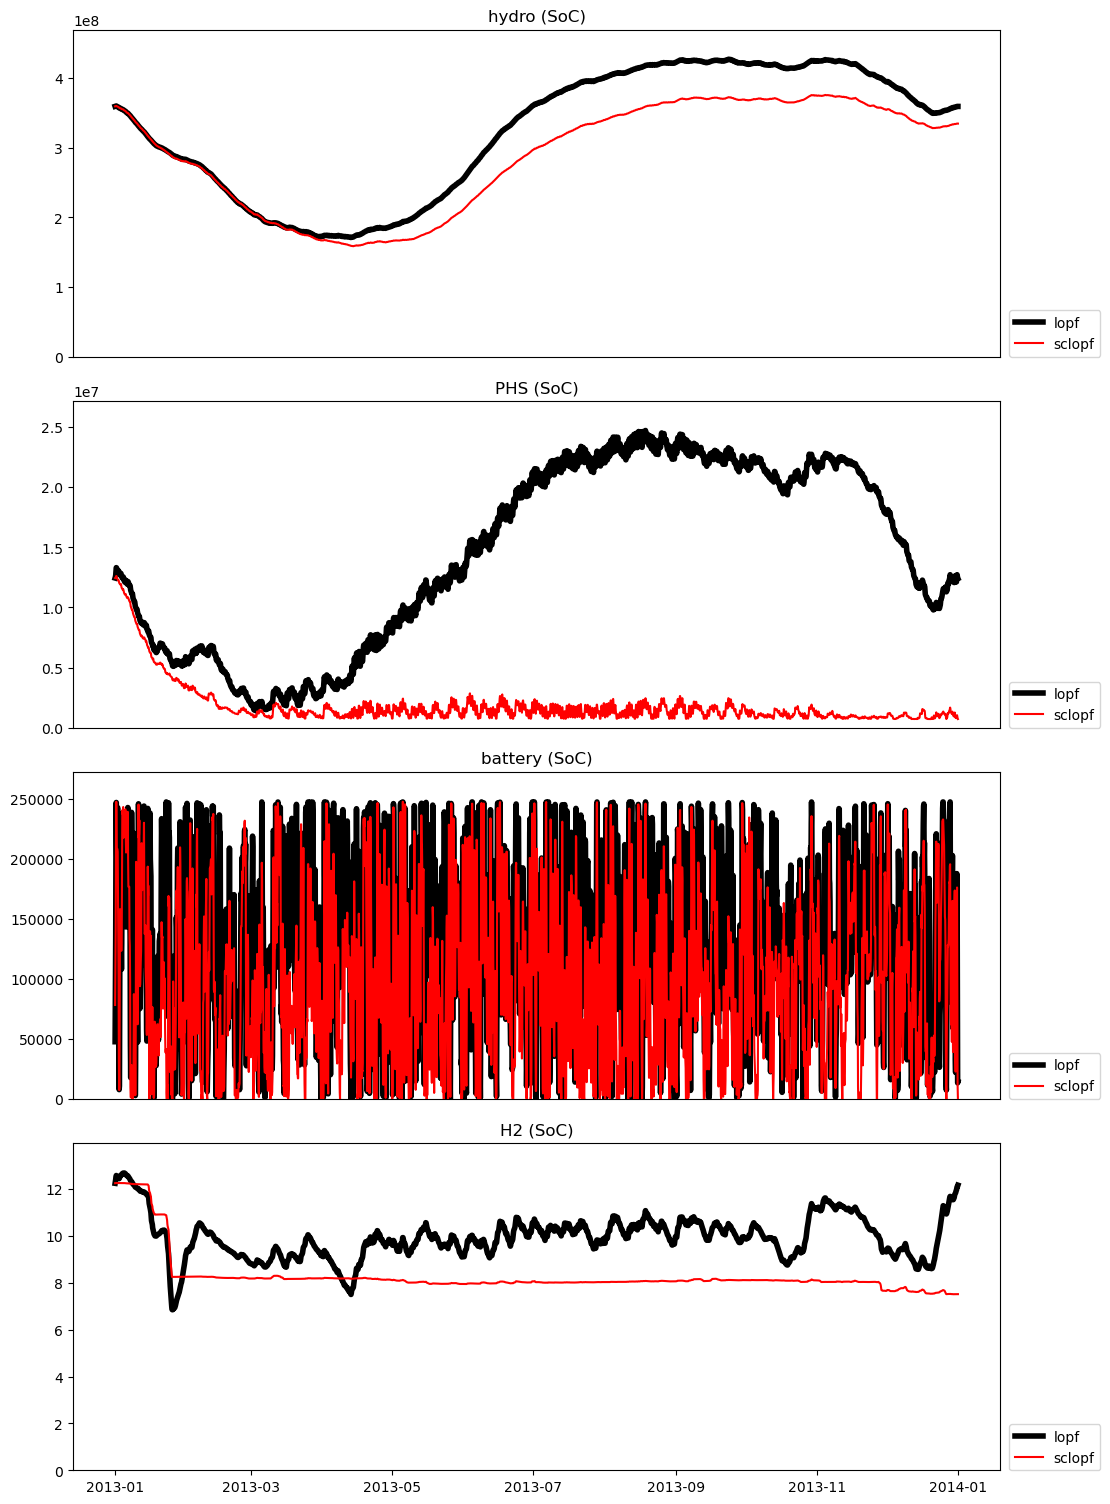

In [10]:
fig, axes = plt.subplots(len(nLopf.storage_units.carrier.unique()), 1, figsize=(10, 15))
fig.tight_layout()

c = 0
techsu = nLopf.storage_units.carrier.unique()
for ax in axes:
    tech = techsu[c]
    disp_n = nLopf.storage_units_t.state_of_charge.multiply(nLopf.snapshot_weightings.objective,axis=0).T.groupby(nLopf.storage_units.carrier).sum().T[tech].loc[snapshots]
    disp_i = nSclopf.storage_units_t.state_of_charge.multiply(nSclopf.snapshot_weightings.objective,axis=0).T.groupby(nSclopf.storage_units.carrier).sum().T[tech].loc[snapshots]

    ax.set_title(tech + " (SoC)")
    ax.plot(disp_n, color="black", linewidth=4, label="lopf")
    ax.plot(disp_i, color="red", zorder=3, label="sclopf")
    ax.set_ylim([min([0, min(disp_n), min(disp_i)]), max([max(disp_n*1.1), max(disp_i*1.1)])])
    ax.legend(loc=[1.01, 0])
    if tech != "H2": ax.set_xticks([], [])
    c = c+1
    


Text(0.5, 0.98, 'p')

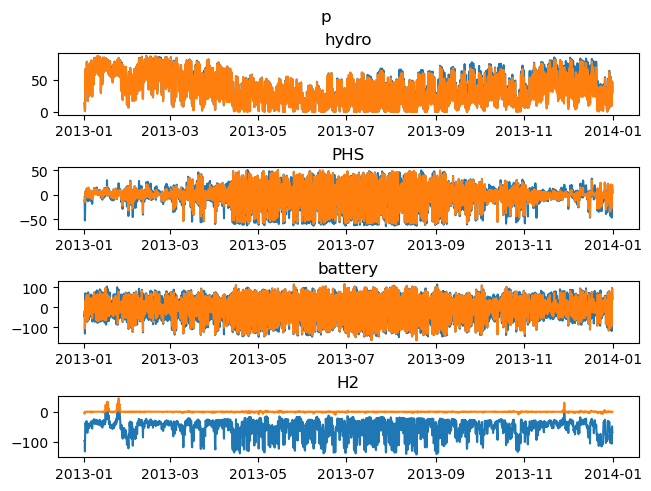

In [11]:
p_lopf = nLopf.storage_units_t.p.divide(nLopf.storage_units.p_nom).T.groupby(nLopf.storage_units.carrier).sum()
p_sclopf = nSclopf.storage_units_t.p.divide(nSclopf.storage_units.p_nom).T.groupby(nSclopf.storage_units.carrier).sum()



carrs = nLopf.storage_units.carrier.unique()

fig,ax = plt.subplots(len(carrs),1, layout = 'constrained')

for cx,carr in enumerate(carrs):
    

    ax[cx].plot(p_lopf.loc[carr], label = 'lopf')
    ax[cx].plot(p_sclopf.loc[carr], label = 'sclopf')
    # ax[cx].suptitle(carr)
    ax[cx].set_title(carr)
    
fig.suptitle('p')




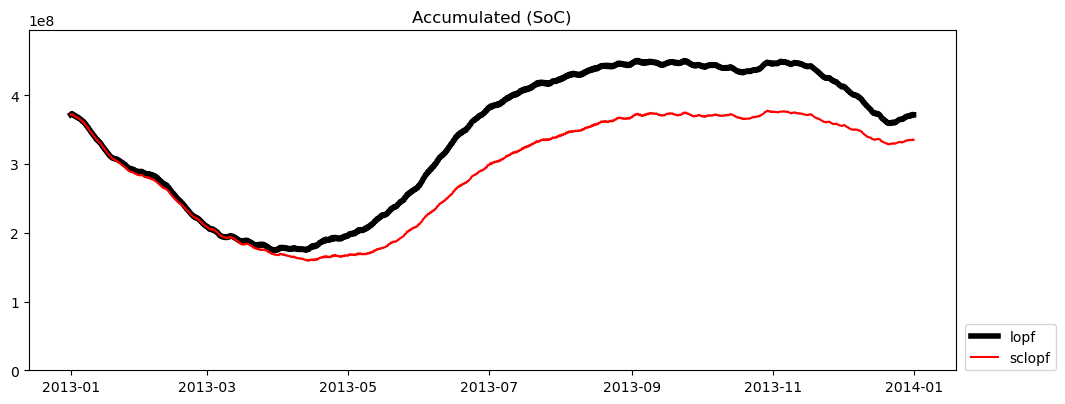

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
fig.tight_layout()


disp_n = nLopf.storage_units_t.state_of_charge.multiply(nLopf.snapshot_weightings.objective,axis=0).T.groupby(nLopf.storage_units.carrier).sum().sum().loc[snapshots]
disp_i = nSclopf.storage_units_t.state_of_charge.multiply(nSclopf.snapshot_weightings.objective,axis=0).T.groupby(nSclopf.storage_units.carrier).sum().sum().loc[snapshots]

ax.set_title("Accumulated (SoC)")
ax.plot(disp_n, color="black", linewidth=4, label="lopf")
ax.plot(disp_i, color="red", zorder=3, label="sclopf")
ax.set_ylim([min([0, min(disp_n), min(disp_i)]), max([max(disp_n*1.1), max(disp_i*1.1)])])
ax.legend(loc=[1.01, 0])

Text(0.5, 0.98, 'dispatch')

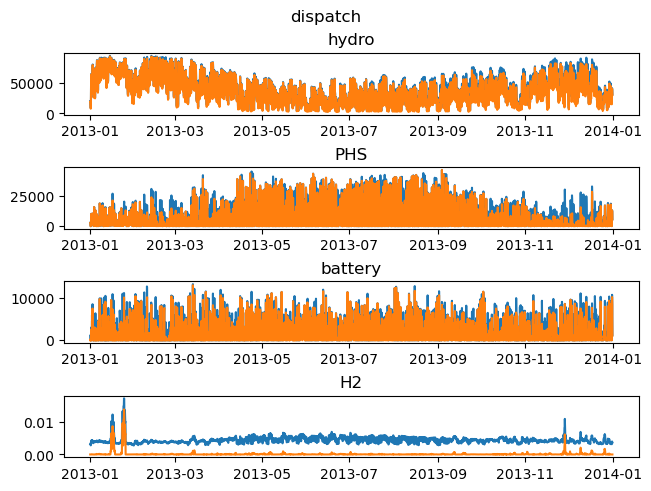

In [71]:
carrs = nLopf.storage_units.carrier.unique()

dis_lopf = nLopf.storage_units_t.p_dispatch.T.groupby(nLopf.storage_units.carrier).sum()
dis_sclopf = nSclopf.storage_units_t.p_dispatch.T.groupby(nSclopf.storage_units.carrier).sum()

fig,ax = plt.subplots(len(carrs),1, layout = 'constrained')

for cx,carr in enumerate(carrs):
    

    ax[cx].plot(dis_lopf.loc[carr], label = 'lopf')
    ax[cx].plot(dis_sclopf.loc[carr], label = 'sclopf')
    # ax[cx].suptitle(carr)
    ax[cx].set_title(carr)
    
fig.suptitle('dispatch')




Text(0.5, 0.98, 'dispatch')

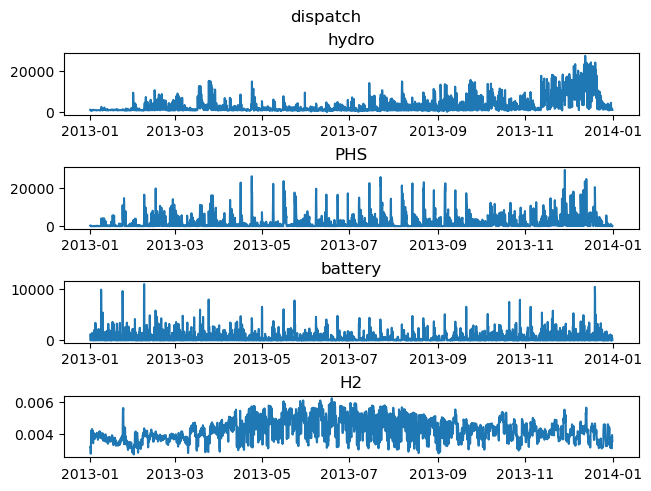

In [13]:
carrs = nLopf.storage_units.carrier.unique()

dis_lopf = nLopf.storage_units_t.p_dispatch.T.groupby(nLopf.storage_units.carrier).sum()
dis_sclopf = nSclopf.storage_units_t.p_dispatch.T.groupby(nSclopf.storage_units.carrier).sum()

fig,ax = plt.subplots(len(carrs),1, layout = 'constrained')

for cx,carr in enumerate(carrs):
    

    ax[cx].plot(dis_lopf.loc[carr]-dis_sclopf.loc[carr])
    # ax[cx].suptitle(carr)
    ax[cx].set_title(carr)
    
fig.suptitle('dispatch')




In [ ]:
nSclopf.storage_units_t.p_store

Text(0.5, 0.98, 'store')

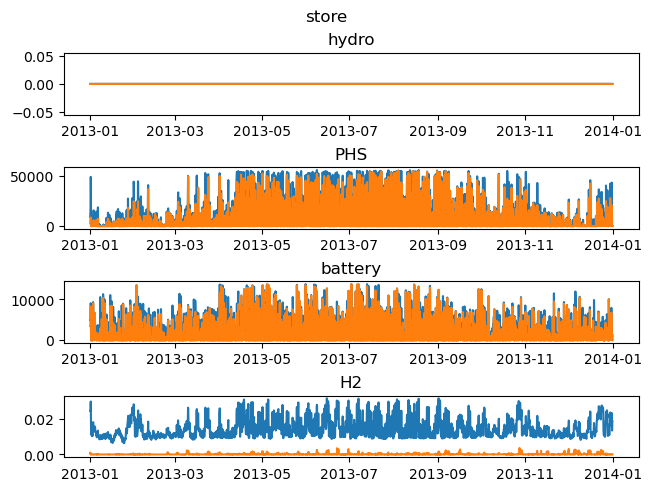

In [14]:

carrs = nLopf.storage_units.carrier.unique()

store_lopf = nLopf.storage_units_t.p_store.T.groupby(nLopf.storage_units.carrier).sum()
store_sclopf = nSclopf.storage_units_t.p_store.T.groupby(nSclopf.storage_units.carrier).sum()

fig,ax = plt.subplots(len(carrs),1, layout = 'constrained')

for cx,carr in enumerate(carrs):
    

    ax[cx].plot(store_lopf.loc[carr], label = 'lopf')
    ax[cx].plot(store_sclopf.loc[carr], label = 'sclopf')
    # ax[cx].suptitle(carr)
    ax[cx].set_title(carr)
    
fig.suptitle('store')
    


    



In [24]:
p_initial = nLopf.generators_t.p.copy()
p_final = nSclopf.generators_t.p.copy()
redispatch = p_final - p_initial
redispatch_summary = redispatch.abs().sum().sum()

# Ausgabe
print("Redispatch-Quantifizierung:")
print(redispatch_summary)

Redispatch-Quantifizierung:
161069100.08501327


In [25]:
nLopf.storage_units_t['p_dispatch'].max()

StorageUnit
AL1 0 hydro    1690.699975
AT1 0 PHS        49.999842
AT1 0 hydro    1060.719813
AT1 1 PHS       478.999882
AT1 1 hydro     983.999936
                  ...     
SE2 5 H2          0.000052
SE2 6 H2          0.000036
SE2 7 H2          0.000766
SI1 0 H2          0.000025
SK1 0 H2          0.000025
Length: 552, dtype: float64